# NCD KAP Study — Exploratory Data Analysis
**Project:** Knowledge, Attitudes, and Practices Toward Non-Communicable Diseases Among Medical Students at the University of Gezira, Sudan, 2026  
**Analyst:** Abdulrahman Sirelkhatim  
**Date:** May 2026  
**Sample:** N = 184 undergraduate medical students

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10

DATA_PATH = "../1_data/cleaned/cleaned_data.xlsx"
df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (184, 54)
Columns: ['ID', 'Age', 'Gender', 'AcadYr', 'Resid', 'Marital', 'FamHist', 'Src_Med', 'Src_SM', 'Src_Net', 'Src_TV', 'Src_Fam', 'Src_Wkshp', 'K01', 'K02', 'K03', 'K04', 'K05', 'K06', 'K07', 'K08', 'K09', 'K10', 'K11', 'K12', 'K13', 'K14', 'K15', 'K16', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'K_Score', 'K_Cat', 'K_Cat2', 'A_Score', 'A_Cat', 'A_Cat2', 'P_Score', 'P_Cat', 'P_High']


## 1. Data Quality

In [3]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values.")

print("\nData types:")
print(df.dtypes.value_counts())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
No missing values.

Data types:
int64    54
Name: count, dtype: int64

Duplicate rows: 0


In [4]:
K_COLS = [f"K{i:02d}" for i in range(1, 17)]
A_COLS = [f"A{i:02d}" for i in range(1, 9)]
P_COLS = [f"P{i:02d}" for i in range(1, 9)]

print("K item value range:", df[K_COLS].stack().unique())
print("A item value range:", sorted(df[A_COLS].stack().unique()))
print("P item value range:", df[P_COLS].stack().unique())

print("\nK_Score range:", df["K_Score"].min(), "–", df["K_Score"].max())
print("A_Score range:", df["A_Score"].min(), "–", df["A_Score"].max())
print("P_Score range:", df["P_Score"].min(), "–", df["P_Score"].max())

K item value range: [1 0]
A item value range: [np.int64(1), np.int64(3), np.int64(4), np.int64(5)]
P item value range: [1 0]

K_Score range: 8 – 16
A_Score range: 22 – 39
P_Score range: 0 – 8


## 2. Demographic Profile

In [5]:
demo_maps = {
    "Age": {1: "<20 yrs", 2: "20–24 yrs", 3: "25–29 yrs"},
    "Gender": {1: "Male", 2: "Female"},
    "AcadYr": {1: "1st", 2: "2nd", 3: "3rd", 4: "4th", 5: "5th", 6: "6th"},
    "Resid": {1: "Urban", 2: "Rural"},
    "Marital": {1: "Single", 2: "Married", 3: "Divorced", 4: "Widowed"},
    "FamHist": {1: "Yes", 2: "No", 3: "Don't Know"},
}

for col, mapping in demo_maps.items():
    counts = df[col].map(mapping).value_counts()
    pcts = counts / len(df) * 100
    table = pd.DataFrame({"n": counts, "%": pcts.round(1)})
    print(f"\n{col}:")
    print(table.to_string())


Age:
             n     %
Age                 
20–24 yrs  176  95.7
<20 yrs      5   2.7
25–29 yrs    3   1.6

Gender:
          n     %
Gender           
Female  138  75.0
Male     46  25.0

AcadYr:
          n     %
AcadYr           
3rd     180  97.8
4th       2   1.1
1st       1   0.5
6th       1   0.5

Resid:
         n     %
Resid           
Urban  129  70.1
Rural   55  29.9

Marital:
           n     %
Marital           
Single   181  98.4
Married    3   1.6

FamHist:
              n     %
FamHist              
Yes         110  59.8
No           63  34.2
Don't Know   11   6.0


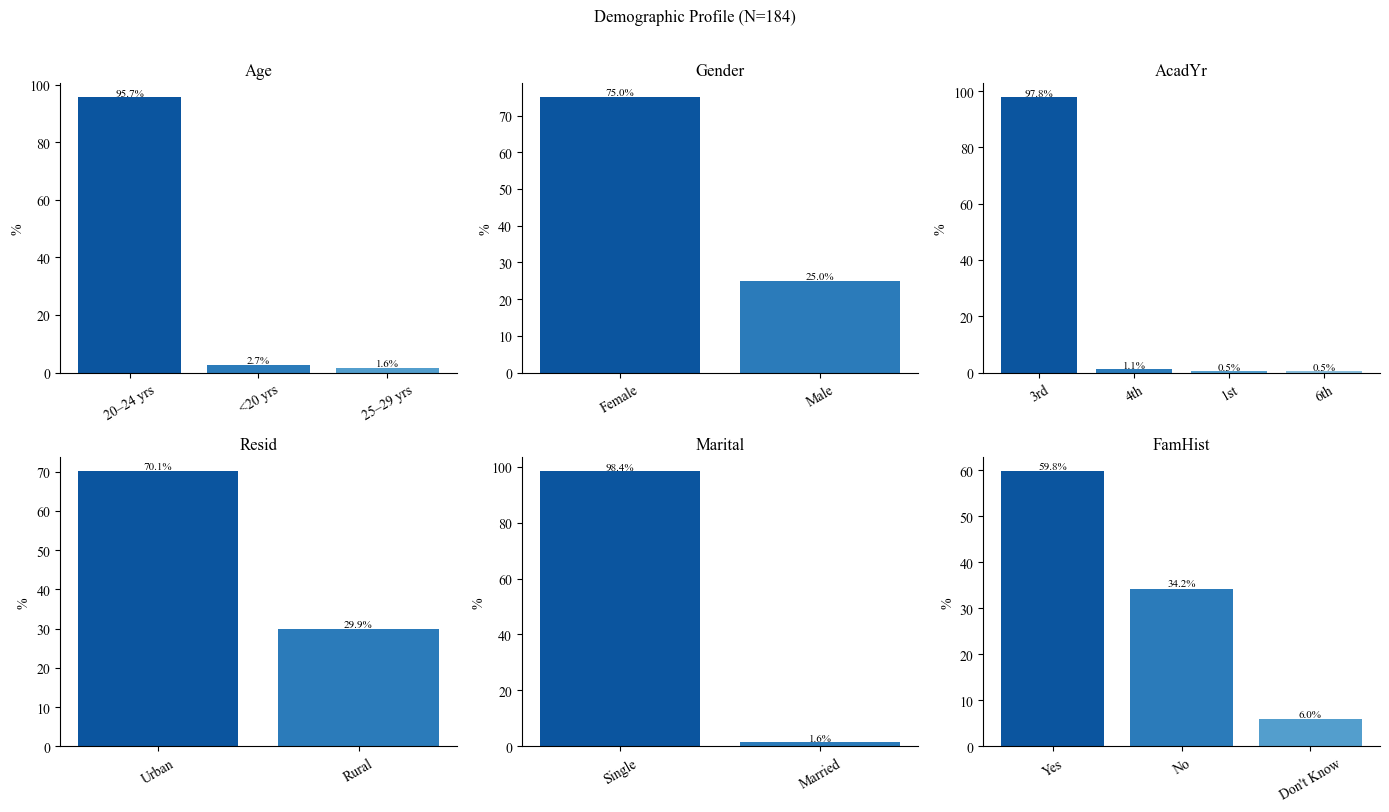

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = sns.color_palette("Blues_r", 6)

for ax, (col, mapping) in zip(axes, demo_maps.items()):
    counts = df[col].map(mapping).value_counts()
    pcts = counts / len(df) * 100
    ax.bar(counts.index, pcts, color=palette[: len(counts)])
    for i, v in enumerate(pcts):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=8)
    ax.set_title(col)
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=30)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Demographic Profile (N=184)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

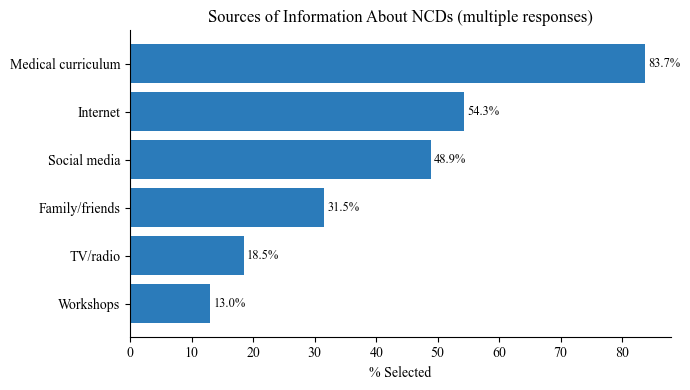

In [7]:
src_cols = ["Src_Med", "Src_Net", "Src_SM", "Src_Fam", "Src_TV", "Src_Wkshp"]
src_labels = [
    "Medical curriculum",
    "Internet",
    "Social media",
    "Family/friends",
    "TV/radio",
    "Workshops",
]

src_pcts = {label: df[col].mean() * 100 for col, label in zip(src_cols, src_labels)}
src_pcts = dict(sorted(src_pcts.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    list(src_pcts.keys()),
    list(src_pcts.values()),
    color=sns.color_palette("Blues_r", 6)[1],
)
for k, v in src_pcts.items():
    ax.text(
        v + 0.5, list(src_pcts.keys()).index(k), f"{v:.1f}%", va="center", fontsize=9
    )
ax.set_xlabel("% Selected")
ax.set_title("Sources of Information About NCDs (multiple responses)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** The sample is 97.8% third-year students — almost zero academic year variance. This collapses any comparison by AcadYr. Gender is 75% female. Family history is positive in 59.8% — this will be important for attitude analysis.

## 3. KAP Score Distributions

In [8]:
print("KAP Score Descriptives:")
print(df[["K_Score", "A_Score", "P_Score"]].describe().round(2))
print()

# Scores as % of max for comparability
print("As % of maximum possible score:")
print(f"  Knowledge: {df['K_Score'].mean() / 16 * 100:.1f}%")
print(f"  Attitude:  {df['A_Score'].mean() / 40 * 100:.1f}%")
print(f"  Practice:  {df['P_Score'].mean() / 8 * 100:.1f}%")

KAP Score Descriptives:
       K_Score  A_Score  P_Score
count   184.00   184.00   184.00
mean     15.55    35.72     4.20
std       0.91     2.81     1.58
min       8.00    22.00     0.00
25%      15.00    35.00     3.00
50%      16.00    36.00     4.00
75%      16.00    38.00     5.00
max      16.00    39.00     8.00

As % of maximum possible score:
  Knowledge: 97.2%
  Attitude:  89.3%
  Practice:  52.5%


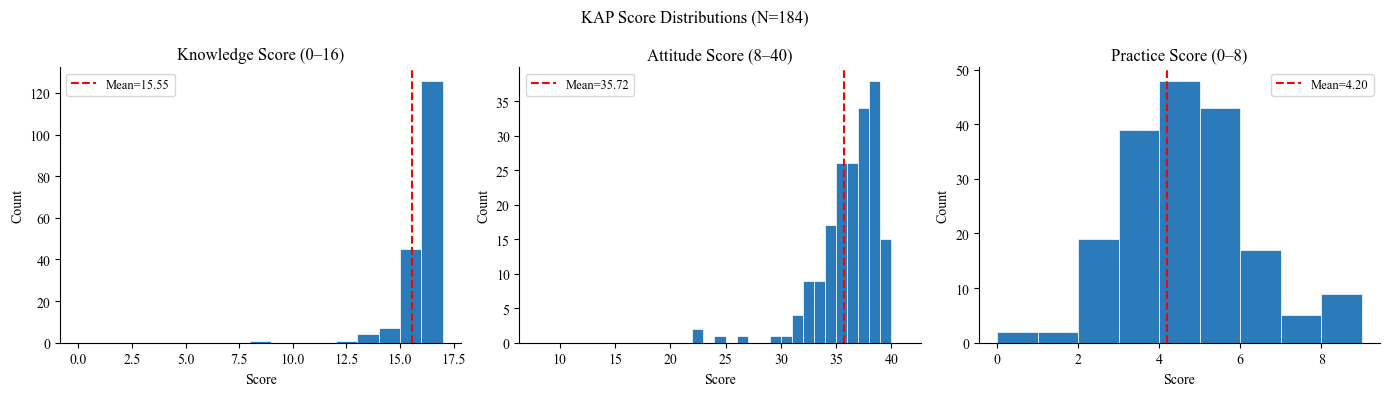

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
blue = sns.color_palette("Blues_r", 6)

configs = [
    ("K_Score", "Knowledge Score (0–16)", (0, 16)),
    ("A_Score", "Attitude Score (8–40)", (8, 40)),
    ("P_Score", "Practice Score (0–8)", (0, 8)),
]

for ax, (col, title, xlim) in zip(axes, configs):
    ax.hist(
        df[col],
        bins=range(int(xlim[0]), int(xlim[1]) + 2),
        color=blue[1],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.axvline(
        df[col].mean(),
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean={df[col].mean():.2f}",
    )
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("KAP Score Distributions (N=184)", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
cat_maps = {
    "K_Cat": ("Knowledge Category", {1: "Poor", 2: "Fair", 3: "Good"}),
    "A_Cat": ("Attitude Category", {1: "Negative", 2: "Neutral", 3: "Positive"}),
    "P_Cat": ("Practice Category", {1: "Low", 2: "Moderate", 3: "High"}),
}

for col, (label, mapping) in cat_maps.items():
    counts = df[col].map(mapping).value_counts()
    pcts = counts / len(df) * 100

    print(f"\n{label}:")
    for cat in mapping.values():
        n = counts.get(cat, 0)
        p = pcts.get(cat, 0)
        print(f"  {cat}: {n} ({p:.1f}%)")


Knowledge Category:
  Poor: 1 (0.5%)
  Fair: 1 (0.5%)
  Good: 182 (98.9%)

Attitude Category:
  Negative: 0 (0.0%)
  Neutral: 5 (2.7%)
  Positive: 179 (97.3%)

Practice Category:
  Low: 23 (12.5%)
  Moderate: 130 (70.7%)
  High: 31 (16.8%)


**Critical observation:** Knowledge and Attitude show extreme ceiling effects:
- Knowledge Good: 98.9% (n=182/184)
- Attitude Positive: 97.3% (n=179/184)

This will severely limit bivariate and multivariate analysis. Practice has a more useful distribution — 12.5% Low, 70.7% Moderate, 16.8% High. Practice is the analytically interesting outcome variable.

## 4. Item-Level Analysis

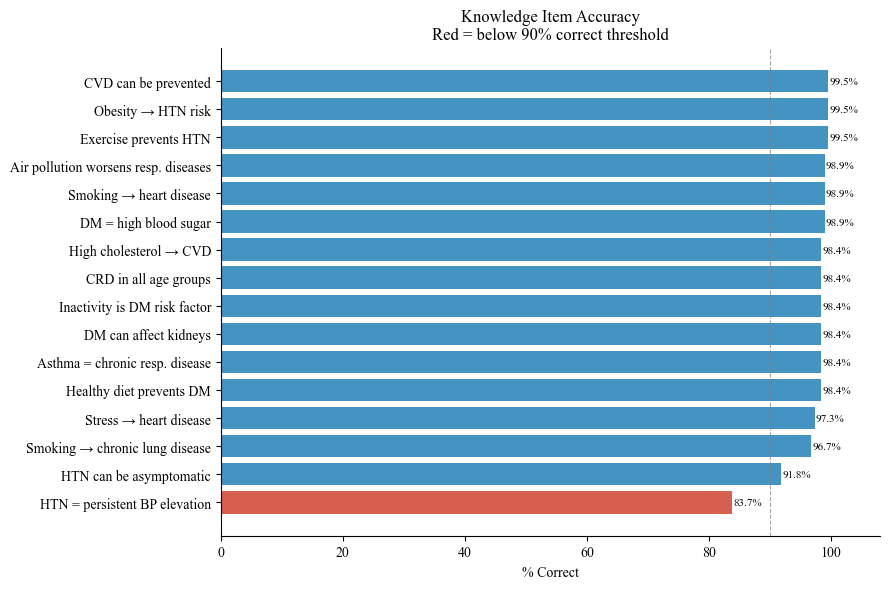


Items below 90% correct: 1
Items at 99%+ correct: 3


In [11]:
K_ITEMS = [
    "HTN = persistent BP elevation",
    "Obesity → HTN risk",
    "HTN can be asymptomatic",
    "Exercise prevents HTN",
    "DM = high blood sugar",
    "Inactivity is DM risk factor",
    "DM can affect kidneys",
    "Healthy diet prevents DM",
    "Smoking → heart disease",
    "High cholesterol → CVD",
    "Stress → heart disease",
    "CVD can be prevented",
    "Smoking → chronic lung disease",
    "Asthma = chronic resp. disease",
    "Air pollution worsens resp. diseases",
    "CRD in all age groups",
]

k_pcts = [df[f"K{i:02d}"].mean() * 100 for i in range(1, 17)]
k_df = pd.DataFrame({"Item": K_ITEMS, "Correct_%": k_pcts}).sort_values("Correct_%")

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#4393c3" if v >= 90 else "#d6604d" for v in k_df["Correct_%"]]
ax.barh(k_df["Item"], k_df["Correct_%"], color=colors)
ax.axvline(90, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
for i, v in enumerate(k_df["Correct_%"]):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=8)
ax.set_xlabel("% Correct")
ax.set_title("Knowledge Item Accuracy\nRed = below 90% correct threshold")
ax.set_xlim(0, 108)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nItems below 90% correct: {sum(1 for v in k_pcts if v < 90)}")
print(f"Items at 99%+ correct: {sum(1 for v in k_pcts if v >= 99)}")

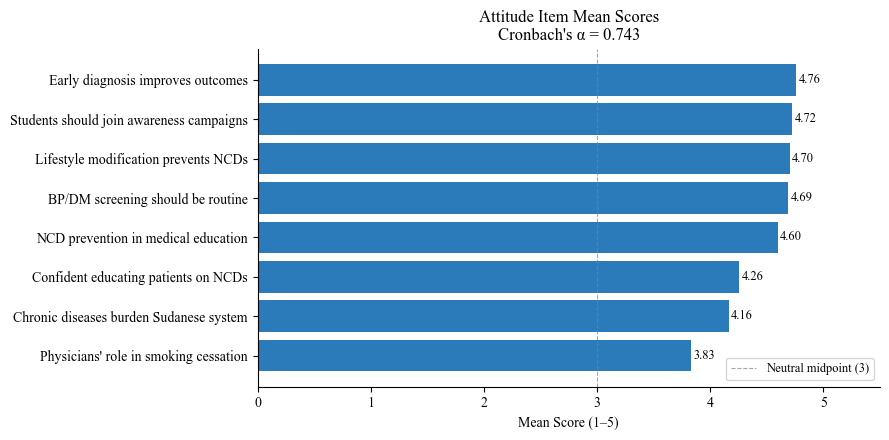


All means above 3 (neutral): True
Lowest: A05 (smoking cessation role) = 3.83
Highest: A08 (early diagnosis) = 4.76


In [12]:
A_ITEMS = [
    "NCD prevention in medical education",
    "Students should join awareness campaigns",
    "Lifestyle modification prevents NCDs",
    "BP/DM screening should be routine",
    "Physicians' role in smoking cessation",
    "Chronic diseases burden Sudanese system",
    "Confident educating patients on NCDs",
    "Early diagnosis improves outcomes",
]

a_means = [df[f"A{i:02d}"].mean() for i in range(1, 9)]
a_df = pd.DataFrame({"Item": A_ITEMS, "Mean": a_means}).sort_values("Mean")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(a_df["Item"], a_df["Mean"], color=sns.color_palette("Blues_r", 6)[1])
ax.axvline(
    3,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7,
    label="Neutral midpoint (3)",
)
for i, v in enumerate(a_df["Mean"]):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlabel("Mean Score (1–5)")
ax.set_title("Attitude Item Mean Scores\nCronbach's α = 0.743")
ax.set_xlim(0, 5.5)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nAll means above 3 (neutral): {all(v > 3 for v in a_means)}")
print(f"Lowest: A05 (smoking cessation role) = {min(a_means):.2f}")
print(f"Highest: A08 (early diagnosis) = {max(a_means):.2f}")

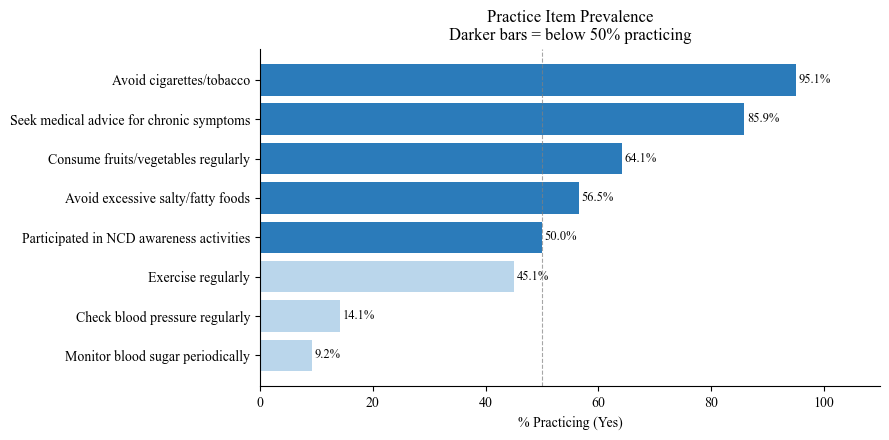


Items below 50%: 3
Items above 80%: 2
Lowest practice: P03 (blood sugar monitoring) = 9.2%
Highest practice: P04 (tobacco avoidance) = 95.1%


In [13]:
P_ITEMS = [
    "Exercise regularly",
    "Check blood pressure regularly",
    "Monitor blood sugar periodically",
    "Avoid cigarettes/tobacco",
    "Consume fruits/vegetables regularly",
    "Avoid excessive salty/fatty foods",
    "Participated in NCD awareness activities",
    "Seek medical advice for chronic symptoms",
]

p_pcts = [df[f"P{i:02d}"].mean() * 100 for i in range(1, 9)]
p_df = pd.DataFrame({"Item": P_ITEMS, "Pct_Yes": p_pcts}).sort_values("Pct_Yes")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [
    sns.color_palette("Blues_r", 6)[4] if v < 50 else sns.color_palette("Blues_r", 6)[1]
    for v in p_df["Pct_Yes"]
]
ax.barh(p_df["Item"], p_df["Pct_Yes"], color=colors)
ax.axvline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
for i, v in enumerate(p_df["Pct_Yes"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% Practicing (Yes)")
ax.set_title("Practice Item Prevalence\nDarker bars = below 50% practicing")
ax.set_xlim(0, 110)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nItems below 50%: {sum(1 for v in p_pcts if v < 50)}")
print(f"Items above 80%: {sum(1 for v in p_pcts if v > 80)}")
print(f"Lowest practice: P03 (blood sugar monitoring) = {min(p_pcts):.1f}%")
print(f"Highest practice: P04 (tobacco avoidance) = {max(p_pcts):.1f}%")

## 5. The Knowledge–Practice Gap

In [14]:
# The defining feature of this study: near-perfect knowledge, moderate practice only.
# This cell quantifies the gap for key matched pairs.

gaps = {
    "HTN asymptomatic → check BP": (df["K03"].mean() * 100, df["P02"].mean() * 100),
    "DM affects kidneys → monitor glucose": (
        df["K07"].mean() * 100,
        df["P03"].mean() * 100,
    ),
    "Exercise prevents HTN → exercise regularly": (
        df["K04"].mean() * 100,
        df["P01"].mean() * 100,
    ),
    "Healthy diet prevents DM → eat fruits/veg": (
        df["K08"].mean() * 100,
        df["P05"].mean() * 100,
    ),
    "CVD can be prevented → avoid fatty foods": (
        df["K12"].mean() * 100,
        df["P06"].mean() * 100,
    ),
}

print("Knowledge–Practice Gap Summary:")
print(f"{'Pair':<45} {'Know%':>6}  {'Practice%':>9}  {'Gap':>6}")
print("-" * 70)
for pair, (k, p) in gaps.items():
    print(f"{pair:<45} {k:>6.1f}%  {p:>9.1f}%  {k - p:>5.1f}%")

Knowledge–Practice Gap Summary:
Pair                                           Know%  Practice%     Gap
----------------------------------------------------------------------
HTN asymptomatic → check BP                     91.8%       14.1%   77.7%
DM affects kidneys → monitor glucose            98.4%        9.2%   89.1%
Exercise prevents HTN → exercise regularly      99.5%       45.1%   54.3%
Healthy diet prevents DM → eat fruits/veg       98.4%       64.1%   34.2%
CVD can be prevented → avoid fatty foods        99.5%       56.5%   42.9%


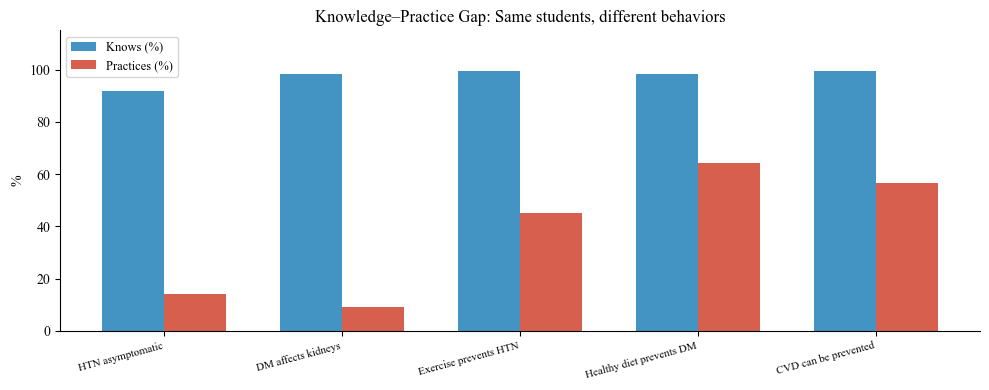

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(gaps))
labels = list(gaps.keys())
k_vals = [v[0] for v in gaps.values()]
p_vals = [v[1] for v in gaps.values()]
w = 0.35

b1 = ax.bar(x - w / 2, k_vals, w, label="Knows (%)", color="#4393c3")
b2 = ax.bar(x + w / 2, p_vals, w, label="Practices (%)", color="#d6604d")

ax.set_xticks(x)
ax.set_xticklabels(
    [label.split("→")[0].strip() for label in labels],
    fontsize=8,
    rotation=15,
    ha="right",
)
ax.set_ylabel("%")
ax.set_title("Knowledge–Practice Gap: Same students, different behaviors")
ax.legend(fontsize=9)
ax.set_ylim(0, 115)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Preliminary Associations

In [16]:
# Practice score by Gender
male = df[df["Gender"] == 1]["P_Score"]
female = df[df["Gender"] == 2]["P_Score"]

print("Practice Score by Gender:")
print(f"  Male (n={len(male)}): mean={male.mean():.2f}, SD={male.std():.2f}")
print(f"  Female (n={len(female)}): mean={female.mean():.2f}, SD={female.std():.2f}")
t, p = stats.ttest_ind(male, female)
print(f"  t-test: t={t:.3f}, p={p:.3f}")

Practice Score by Gender:
  Male (n=46): mean=4.28, SD=1.89
  Female (n=138): mean=4.17, SD=1.47
  t-test: t=0.403, p=0.688


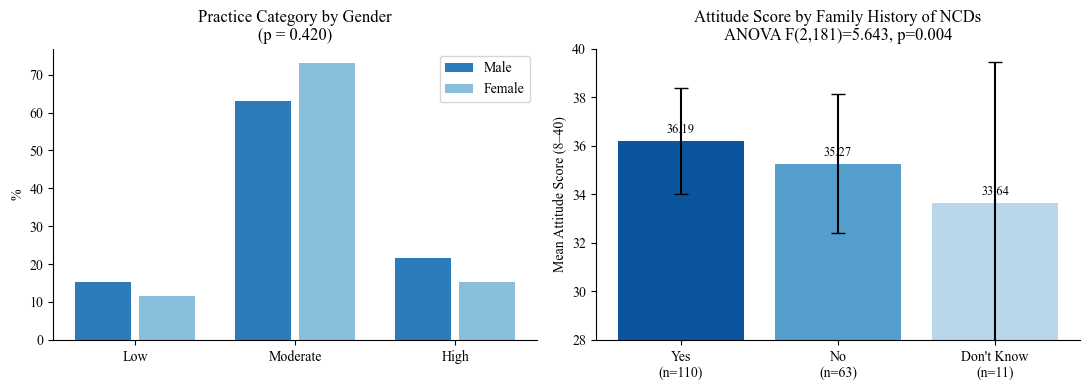

In [17]:
# Practice category distribution by Gender
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
blue = sns.color_palette("Blues_r", 6)
gender_map = {1: "Male", 2: "Female"}

ax = axes[0]
p_cat_map = {1: "Low", 2: "Moderate", 3: "High"}
for gender_code, label in gender_map.items():
    subset = (
        df[df["Gender"] == gender_code]["P_Cat"]
        .map(p_cat_map)
        .value_counts(normalize=True)
        * 100
    )
    subset = subset.reindex(["Low", "Moderate", "High"])
    x = np.arange(3)
    offset = -0.2 if gender_code == 1 else 0.2
    ax.bar(
        x + offset,
        subset.values,
        0.35,
        label=label,
        color=blue[1] if gender_code == 1 else blue[3],
    )
ax.set_xticks(np.arange(3))
ax.set_xticklabels(["Low", "Moderate", "High"])
ax.set_ylabel("%")
ax.set_title("Practice Category by Gender\n(p = 0.420)")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Attitude score by Family History
ax = axes[1]
fh_map = {1: "Yes", 2: "No", 3: "Don't Know"}
means = df.groupby("FamHist")["A_Score"].mean().reindex([1, 2, 3])
sds = df.groupby("FamHist")["A_Score"].std().reindex([1, 2, 3])
tick_labels = ["Yes\n(n=110)", "No\n(n=63)", "Don't Know\n(n=11)"]
bars = ax.bar(
    tick_labels,
    means.values,
    yerr=sds.values,
    capsize=5,
    color=[blue[0], blue[2], blue[4]],
)
for bar, v in zip(bars, means.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.2,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_ylabel("Mean Attitude Score (8–40)")
ax.set_title("Attitude Score by Family History of NCDs\nANOVA F(2,181)=5.643, p=0.004")
ax.set_ylim(28, 40)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
# Gender × Attitude: the one significant bivariate association
ct = (
    pd.crosstab(
        df["Gender"].map({1: "Male", 2: "Female"}),
        df["A_Cat2"].map({0: "Neg./Neutral", 1: "Positive"}),
        normalize="index",
    )
    * 100
)

print("Attitude Category (binary) by Gender (row %):")
print(ct.round(1))
print("\nFisher's Exact p = 0.014")
print("Males have 8.7% Negative/Neutral vs 0.7% for Females")

Attitude Category (binary) by Gender (row %):
A_Cat2  Neg./Neutral  Positive
Gender                        
Female           0.7      99.3
Male             8.7      91.3

Fisher's Exact p = 0.014
Males have 8.7% Negative/Neutral vs 0.7% for Females


In [19]:
# Information source × Knowledge: medical curriculum is the one significant predictor
print("Knowledge Good % by Medical Curriculum as Source:")
for selected, label in [(1, "Curriculum selected"), (0, "Not selected")]:
    subset = df[df["Src_Med"] == selected]
    good_pct = (subset["K_Cat"] == 3).mean() * 100
    poor_fair_pct = 100 - good_pct
    print(
        f"  {label} (n={len(subset)}): Good={good_pct:.1f}%, Poor/Fair={poor_fair_pct:.1f}%"
    )
print("\nFisher's Exact p = 0.026")

Knowledge Good % by Medical Curriculum as Source:
  Curriculum selected (n=154): Good=100.0%, Poor/Fair=0.0%
  Not selected (n=30): Good=93.3%, Poor/Fair=6.7%

Fisher's Exact p = 0.026


In [20]:
# Workshops × Practice: borderline significant (Pearson p=0.051, LR p=0.014)
print("Practice Category distribution by Workshops attendance:")
for selected, label in [
    (1, "Attended workshops (n=24)"),
    (0, "Did not attend (n=160)"),
]:
    subset = df[df["Src_Wkshp"] == selected]
    cats = (
        subset["P_Cat"]
        .map({1: "Low", 2: "Moderate", 3: "High"})
        .value_counts(normalize=True)
        * 100
    )
    print(
        f"  {label}: Low={cats.get('Low', 0):.1f}%, Moderate={cats.get('Moderate', 0):.1f}%, High={cats.get('High', 0):.1f}%"
    )
print("\nLikelihood Ratio p = 0.014 | Pearson chi-square p = 0.051 (borderline)")

Practice Category distribution by Workshops attendance:
  Attended workshops (n=24): Low=0.0%, Moderate=70.8%, High=29.2%
  Did not attend (n=160): Low=14.4%, Moderate=70.6%, High=15.0%

Likelihood Ratio p = 0.014 | Pearson chi-square p = 0.051 (borderline)


## 7. Correlation Analysis

In [21]:
corr_vars = ["K_Score", "A_Score", "P_Score"]
corr_labels = ["Knowledge", "Attitude", "Practice"]

print("Pearson correlations between KAP scores:")
for i in range(len(corr_vars)):
    for j in range(i + 1, len(corr_vars)):
        r, p = stats.pearsonr(df[corr_vars[i]], df[corr_vars[j]])
        print(f"  {corr_labels[i]} ↔ {corr_labels[j]}: r={r:.3f}, p={p:.3f}")

Pearson correlations between KAP scores:
  Knowledge ↔ Attitude: r=0.425, p=0.000
  Knowledge ↔ Practice: r=-0.016, p=0.825
  Attitude ↔ Practice: r=0.134, p=0.069


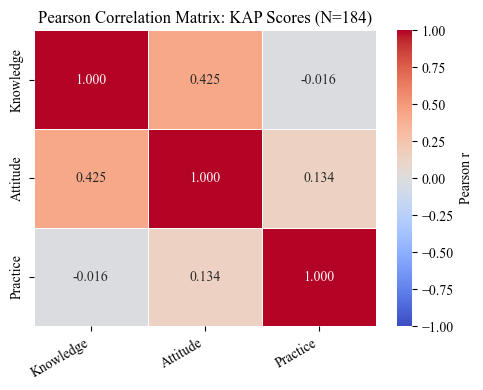

In [22]:
rho = df[corr_vars].corr()
rho.index = corr_labels
rho.columns = corr_labels

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    rho,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix: KAP Scores (N=184)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

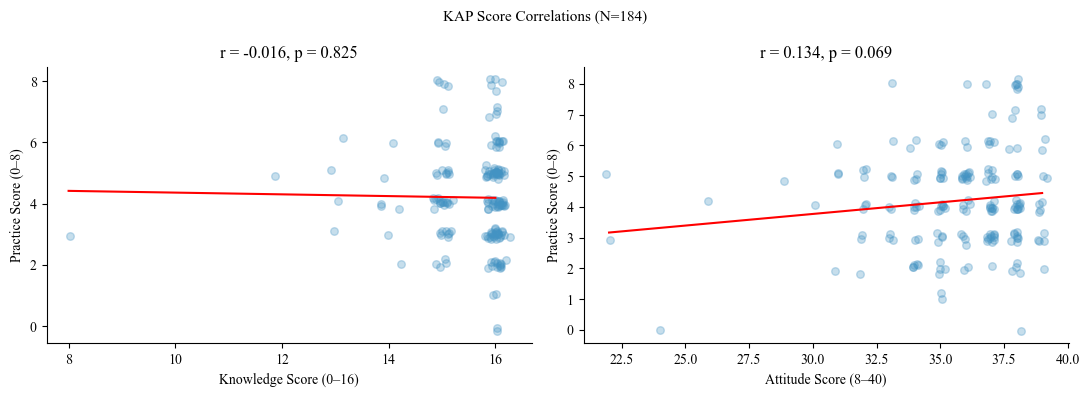

In [23]:
# Scatter: K_Score vs P_Score — the key KAP gap visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (x_col, y_col, x_label, y_label) in zip(
    axes,
    [
        ("K_Score", "P_Score", "Knowledge Score (0–16)", "Practice Score (0–8)"),
        ("A_Score", "P_Score", "Attitude Score (8–40)", "Practice Score (0–8)"),
    ],
):
    r, p_val = stats.pearsonr(df[x_col], df[y_col])
    ax.scatter(
        df[x_col] + np.random.normal(0, 0.1, len(df)),
        df[y_col] + np.random.normal(0, 0.1, len(df)),
        alpha=0.3,
        color="#4393c3",
        s=30,
    )
    m, b = np.polyfit(df[x_col], df[y_col], 1)
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, "r-", linewidth=1.5)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"r = {r:.3f}, p = {p_val:.3f}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("KAP Score Correlations (N=184)", fontsize=11)
plt.tight_layout()
plt.show()

## 8. EDA Summary

## Summary of EDA Findings

| Finding | Value |
|---------|-------|
| Sample size | N = 184 |
| Female participants | 75.0% |
| Age 20–24 years | 95.7% |
| Third-year students | 97.8% |
| Family history of NCDs | 59.8% |
| Main information source | Medical curriculum (83.7%) |
| Mean Knowledge score | 15.55 ± 0.91 / 16 |
| Good Knowledge | 98.9% |
| Mean Attitude score | 35.72 ± 2.81 / 40 |
| Positive Attitude | 97.3% |
| Mean Practice score | 4.20 ± 1.58 / 8 |
| High Practice | 16.8% |
| Lowest Knowledge item | K01: HTN definition (83.7% correct) |
| Lowest Practice item | P03: Blood sugar monitoring (9.2%) |
| Significant associations | Gender × Attitude (p=0.014); Family History × Attitude (p=0.004); Medical Curriculum × Knowledge (p=0.026) |
| KAP gap | High knowledge and positive attitudes did not translate into high preventive practice |
| Ceiling effect | Severe in Knowledge (98.9% Good) and Attitude (97.3% Positive) |

Formal bivariate, ANOVA, and logistic regression analyses were conducted in SPSS (see `4_analysis/full_analysis.sps`).